In [ ]:
import os
import subprocess
import sys

REPO_DIR = "/content/fitnova"
REPO_URL = "https://github.com/Ibrahim-Shahin1/fitnova.git"
BRANCH = "fresh-start"

if not os.path.isdir(REPO_DIR):
    print(f"Cloning {REPO_URL} (branch {BRANCH}) -> {REPO_DIR} ...")
    subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL, REPO_DIR], check=True)
else:
    print(f"Repo already at {REPO_DIR}; pulling latest from origin/{BRANCH} ...")
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "checkout", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH], check=True)

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

_head = subprocess.run(
    ["git", "-C", REPO_DIR, "rev-parse", "--short", "HEAD"],
    capture_output=True, text=True, check=True,
).stdout.strip()
print(f"\nRepo ready: {REPO_DIR} @ {_head}")
print(f"sys.path[0]: {sys.path[0]}")
print(f"cwd: {os.getcwd()}")

for _m in [
    "backend/training/aqa/datasets/ohp.py",
    "backend/training/aqa/datasets/ohp_ssl.py",
]:
    print(f"  {'OK ' if os.path.isfile(_m) else 'MISSING'} {_m}")

Repo already at /content/fitnova; pulling latest from origin/fresh-start ...

Repo ready: /content/fitnova @ e97157d
sys.path[0]: /content/fitnova
cwd: /content/fitnova
  OK  backend/training/aqa/datasets/ohp.py
  OK  backend/training/aqa/datasets/ohp_ssl.py


In [ ]:
import importlib, sys
for m in ["backend.training.aqa.datasets.ohp_ssl"]:
    if m in sys.modules: importlib.reload(sys.modules[m])
print("reloaded ohp_ssl (rglob)")

reloaded ohp_ssl (rglob)


In [ ]:
from backend.training.aqa.harness import _envinit  # CUBLAS_WORKSPACE_CONFIG before torch
import importlib.metadata, os, shutil, subprocess, sys

try:
    import av; _pyav_status = "already installed"
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "av"], check=True); import av; _pyav_status = "installed now"
print(f"PyAV {av.__version__} ({_pyav_status})")

_PHASE6_DEPS = ["torch", "torchvision", "scikit-learn", "matplotlib", "tqdm", "numpy", "scipy"]
print("\n[supply-chain] Dependency versions:")
for _pkg in _PHASE6_DEPS:
    print(f"  {_pkg:<14} {importlib.metadata.version(_pkg)}")

import torch, torchvision
print("\ntorch:", torch.__version__, "| torchvision:", torchvision.__version__, "| CUDA:", torch.cuda.is_available())
assert torch.cuda.is_available(), "GPU required — Runtime > Change runtime type > L4"
_gpu_name = torch.cuda.get_device_name(0); _vram_gb = torch.cuda.get_device_properties(0).total_memory/(1024**3)
print(f"CUDA device : {_gpu_name} ({_vram_gb:.1f} GB VRAM)")
assert "L4" in _gpu_name or _vram_gb >= 22.0, f"Expecting an L4 (>=22 GB); got {_gpu_name} {_vram_gb:.1f} GB."

# decode-backend report (no hard-fail): tv>=0.26 removed read_video -> decode_clip falls back to cv2.
from backend.training.aqa.datasets.transforms import _HAS_TV_READ_VIDEO
if _HAS_TV_READ_VIDEO:
    print(f"decode backend: torchvision.read_video (tv {torchvision.__version__}, PyAV {av.__version__})")
else:
    import cv2
    print(f"decode backend: cv2 fallback (tv {torchvision.__version__} removed read_video; OpenCV {cv2.__version__})")

from google.colab import drive
drive.mount('/content/drive')
MYDRIVE = '/content/drive/MyDrive'; ROOT = os.path.join(MYDRIVE, 'Fitness-AQA_dataset_release')
print("\nROOT :", ROOT, "| exists:", os.path.exists(ROOT))

from pathlib import Path
from backend.training.aqa.harness.colab import stage_ohp_videos, stage_unlabeled_ohp_videos
for _lbl, _rel in [("labeled videos.zip","OHP/Labeled_Dataset/videos.zip"),
                   ("unlabeled videos.zip","OHP/Unlabeled_Dataset/videos.zip"),
                   ("trajectories.zip","OHP/Unlabeled_Dataset/bar_trajectories_raw.zip")]:
    _z = Path(ROOT)/_rel
    if _z.is_file(): print(f"[disk] {_lbl:<22}: {_z.stat().st_size/1e9:.2f} GB")
print(f"[disk] free /content        : {shutil.disk_usage('/content').free/1e9:.1f} GB")

VIDEOS_ROOT = stage_ohp_videos(MYDRIVE)
_labeled_n = len(list(Path(VIDEOS_ROOT).glob('*.mp4')))
print(f"\nLABELED VIDEOS_ROOT: {VIDEOS_ROOT} | mp4 count: {_labeled_n} (expected 2367)")
assert _labeled_n == 2367, f"Expected 2367 labeled mp4s, got {_labeled_n}"

UNLABELED_VIDEOS_ROOT, TRAJ_ROOT = stage_unlabeled_ohp_videos(MYDRIVE, MYDRIVE)
_unlabeled_n = len(list(Path(UNLABELED_VIDEOS_ROOT).glob('*.mp4')))
print(f"\nUNLABELED_VIDEOS_ROOT: {UNLABELED_VIDEOS_ROOT} | mp4 count: {_unlabeled_n} (expected 5490)")
print(f"TRAJ_ROOT: {TRAJ_ROOT}")
assert _unlabeled_n == 5490, f"Expected 5490 unlabeled mp4s, got {_unlabeled_n}"

PyAV 17.0.1 (already installed)

[supply-chain] Dependency versions:
  torch          2.11.0+cu128
  torchvision    0.26.0+cu128
  scikit-learn   1.6.1
  matplotlib     3.10.0
  tqdm           4.67.3
  numpy          2.0.2
  scipy          1.16.3

torch: 2.11.0+cu128 | torchvision: 0.26.0+cu128 | CUDA: True
CUDA device : NVIDIA L4 (22.0 GB VRAM)
decode backend: cv2 fallback (tv 0.26.0+cu128 removed read_video; OpenCV 4.13.0)
Mounted at /content/drive

ROOT : /content/drive/MyDrive/Fitness-AQA_dataset_release | exists: True
[disk] labeled videos.zip    : 0.91 GB
[disk] unlabeled videos.zip  : 1.85 GB
[disk] trajectories.zip      : 0.01 GB
[disk] free /content        : 202.1 GB



LABELED VIDEOS_ROOT: /content/ohp_videos | mp4 count: 2367 (expected 2367)



UNLABELED_VIDEOS_ROOT: /content/ohp_unlabeled_videos | mp4 count: 5490 (expected 5490)
TRAJ_ROOT: /content/ohp_trajectories


[1 layout] 5490 .json recursive under /content/ohp_trajectories; 0 FLAT at top
           sample rel path: bar_trajectories_raw/11681_3.json
           LAYOUT = NESTED -> ohp_ssl needs rglob OR trajectories_root=subdir
           => OHPSSLDataset trajectories_root should be: /content/ohp_trajectories/bar_trajectories_raw

[2 BBox structure] inspecting 5 files:
  11681_3.json: top-type=list, n_frames=144
    frame[0] has 3 regions; region_0=[[0, 138, 416, 302, 99]]
    sample non-empty region_0[0]=[0, 138, 416, 302, 99] -> y_center=(138+302)/2=220.0
  11882_1.json: top-type=list, n_frames=82
    frame[0] has 3 regions; region_0=[[39, 75, 311, 177, 97]]
    sample non-empty region_0[0]=[39, 75, 311, 177, 97] -> y_center=(75+177)/2=126.0

[3 y_center + empty freq]:
  11681_3: len=144, empty_region0=0 (0%), y[:3]=[220.0, 220.0, 218.5], range=[56,220]
  11882_1: len=82, empty_region0=0 (0%), y[:3]=[126.0, 125.5, 123.5], range=[26,152]
  11897_2: len=109, empty_region0=0 (0%), y[:3]=[210.0, 

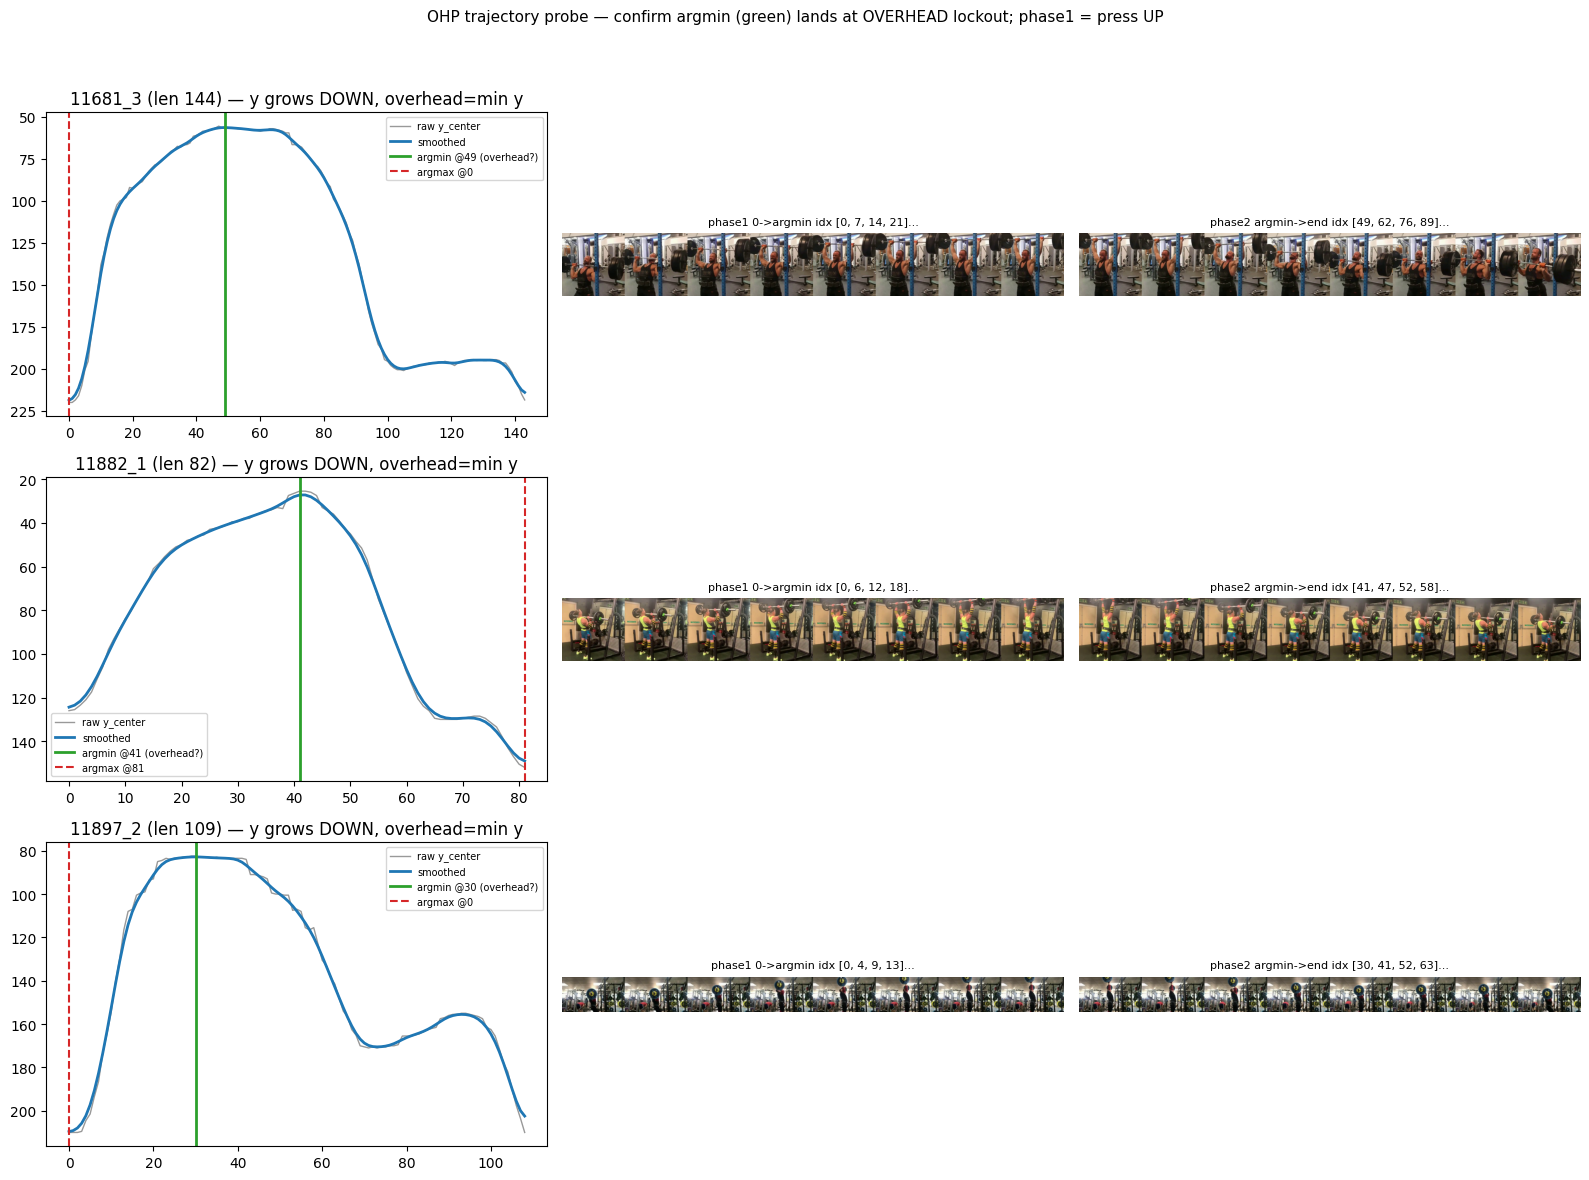


[6 multi-rep] 190/5386 trajectories have >1 prominent extremum (3.5%)

=== PROBE COMPLETE — paste back this report + ohp_traj_probe.png + the resolved sign. NO GPU yet. ===


In [ ]:
import glob, json
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage
import torch
from scipy.signal import find_peaks
from backend.training.aqa.datasets.ohp_ssl import OHPSSLDataset, split_half_cycles
from backend.training.aqa.datasets.transforms import count_frames, decode_clip

FIG_DIR = Path("docs/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)

def _ohp_y_center(data):
    y = np.empty(len(data), dtype=float); n_empty = 0
    for i, frame in enumerate(data):
        region_0 = frame[0] if len(frame) > 0 else []
        if region_0:
            x1, y1, x2, y2, conf = region_0[0]; y[i] = (y1 + y2)/2.0
        else:
            y[i] = np.nan; n_empty += 1
    return y, n_empty

def _interp_nan(y):
    nan = np.isnan(y)
    if nan.any():
        idx = np.arange(len(y)); y = y.copy(); y[nan] = np.interp(idx[nan], idx[~nan], y[~nan])
    return y

all_traj = sorted(glob.glob(os.path.join(TRAJ_ROOT, "**", "*.json"), recursive=True))
flat_traj = sorted(glob.glob(os.path.join(TRAJ_ROOT, "*.json")))
print(f"[1 layout] {len(all_traj)} .json recursive under {TRAJ_ROOT}; {len(flat_traj)} FLAT at top")
if all_traj:
    print(f"           sample rel path: {os.path.relpath(all_traj[0], TRAJ_ROOT)}")
    _is_flat = (len(flat_traj) == len(all_traj))
    print(f"           LAYOUT = {'FLAT (glob ok)' if _is_flat else 'NESTED -> ohp_ssl needs rglob OR trajectories_root=subdir'}")
    print(f"           => OHPSSLDataset trajectories_root should be: {TRAJ_ROOT if _is_flat else os.path.dirname(all_traj[0])}")

sample_files = all_traj[:5]
print(f"\n[2 BBox structure] inspecting {len(sample_files)} files:")
for p in sample_files[:2]:
    with open(p) as fh: data = json.load(fh)
    print(f"  {Path(p).name}: top-type={type(data).__name__}, n_frames={len(data)}")
    f0 = data[0]; print(f"    frame[0] has {len(f0)} regions; region_0={f0[0] if len(f0) else '[]'}")
    for fr in data:
        if len(fr) > 0 and fr[0]:
            print(f"    sample non-empty region_0[0]={fr[0][0]} -> y_center=({fr[0][0][1]}+{fr[0][0][3]})/2={(fr[0][0][1]+fr[0][0][3])/2:.1f}"); break

print(f"\n[3 y_center + empty freq]:")
parsed = []
for p in sample_files:
    with open(p) as fh: data = json.load(fh)
    y_raw, n_empty = _ohp_y_center(data); y = _interp_nan(y_raw); parsed.append((Path(p).stem, y))
    print(f"  {Path(p).stem}: len={len(y)}, empty_region0={n_empty} ({100*n_empty/max(len(y),1):.0f}%), y[:3]={np.round(y[:3],1).tolist()}, range=[{y.min():.0f},{y.max():.0f}]")

_ds = OHPSSLDataset.__new__(OHPSSLDataset)
_ds._traj_paths = {Path(p).stem: Path(p) for p in sample_files}
_cid0 = parsed[0][0]; _parser_y = _ds._load_trajectory(_cid0)
print(f"  ohp_ssl._load_trajectory({_cid0}) matches inline: {np.allclose(_parser_y, parsed[0][1])} (len {len(_parser_y)})")

print(f"\n[4 traj<->frame mapping]:")
for clip_id, y in parsed:
    vpath = os.path.join(UNLABELED_VIDEOS_ROOT, f"{clip_id}.mp4")
    if not os.path.isfile(vpath): print(f"  {clip_id}: video not found"); continue
    try:
        n = count_frames(vpath); r = n/len(y) if len(y) else float("nan")
        print(f"  {clip_id}: traj_len={len(y)} video_frames={n} frames/traj={r:.3f} ({'1:1' if abs(r-1)<0.05 else 'NOT 1:1 — rescale needed'})")
    except Exception as e: print(f"  {clip_id}: count_frames failed -> {e!r}")

n_show = min(3, sum(1 for _, y in parsed if len(y) >= 4)); fig = plt.figure(figsize=(16, 4*max(n_show,1))); row = 0
for clip_id, y in parsed:
    if len(y) < 4 or row >= n_show: continue
    sm = scipy.ndimage.gaussian_filter1d(y, sigma=2.0); b_max, b_min = int(np.argmax(sm)), int(np.argmin(sm))
    ax = fig.add_subplot(n_show, 3, row*3+1)
    ax.plot(y, color="0.6", lw=1, label="raw y_center"); ax.plot(sm, color="C0", lw=2, label="smoothed")
    ax.axvline(b_min, color="C2", ls="-", lw=2, label=f"argmin @{b_min} (overhead?)"); ax.axvline(b_max, color="C3", ls="--", label=f"argmax @{b_max}")
    ax.set_title(f"{clip_id} (len {len(y)}) — y grows DOWN, overhead=min y"); ax.legend(fontsize=7); ax.invert_yaxis()
    vpath = os.path.join(UNLABELED_VIDEOS_ROOT, f"{clip_id}.mp4")
    try:
        desc, asc = split_half_cycles(y, frames_per_half=8, bottom_is_argmax=False)
        for label, idxs, sub in [("phase1 0->argmin", desc, 2), ("phase2 argmin->end", asc, 3)]:
            clip = decode_clip(vpath, torch.as_tensor(np.asarray(idxs), dtype=torch.long))
            strip = torch.cat([clip[k] for k in range(min(8, clip.shape[0]))], dim=2)
            axg = fig.add_subplot(n_show, 3, row*3+sub); axg.imshow(strip.permute(1,2,0).numpy())
            axg.set_title(f"{label} idx {np.asarray(idxs)[:4].tolist()}...", fontsize=8); axg.axis("off")
    except Exception as e: print(f"  [frame grid] {clip_id} failed: {e!r}")
    row += 1
fig.suptitle("OHP trajectory probe — confirm argmin (green) lands at OVERHEAD lockout; phase1 = press UP", fontsize=11)
fig.tight_layout(rect=(0,0,1,0.95)); _png = FIG_DIR/"ohp_traj_probe.png"; fig.savefig(_png, dpi=110, bbox_inches="tight")
print(f"\n[figure] saved {_png}"); plt.show()

multi_rep = 0; total_ok = 0
for p in all_traj:
    try:
        with open(p) as fh: y_raw, _ = _ohp_y_center(json.load(fh))
        if np.isnan(y_raw).all() or (~np.isnan(y_raw)).sum() < 4: continue
        y = _interp_nan(y_raw); sm = scipy.ndimage.gaussian_filter1d(y, sigma=2.0); rng = sm.max()-sm.min()
        if rng <= 0: continue
        peaks, _ = find_peaks(sm, prominence=0.3*rng); valleys, _ = find_peaks(-sm, prominence=0.3*rng)
        total_ok += 1
        if (len(peaks)+len(valleys)) > 1: multi_rep += 1
    except Exception: continue
print(f"\n[6 multi-rep] {multi_rep}/{total_ok} trajectories have >1 prominent extremum ({100*multi_rep/max(total_ok,1):.1f}%)")
print("\n=== Trajectory probe complete: argmin should land at overhead lockout; phase1 = press UP. ===")

len(ssl_ds): 5490 (expected ~5490)
  anchor: (8, 3, 16, 112, 112) torch.float32
  positive: (8, 3, 16, 112, 112) torch.float32
  negative: (8, 3, 16, 112, 112) torch.float32
saved .planning/phases/06-overhead-press/figures/ohp_ssl_triplet_sanity.png


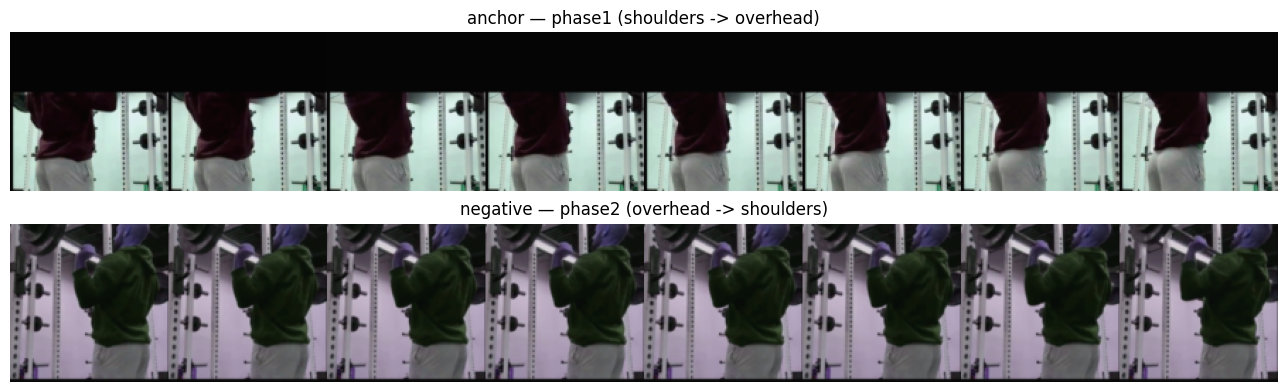

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from pathlib import Path
from backend.training.aqa.datasets.ohp_ssl import OHPSSLDataset, build_ssl_loader
from backend.training.aqa.harness.md_pretrain import MDConfig
from backend.training.aqa.datasets.transforms import KINETICS_MEAN, KINETICS_STD

ssl_ds = OHPSSLDataset(videos_root=UNLABELED_VIDEOS_ROOT, trajectories_root=TRAJ_ROOT, frames_per_half=16, crop_size=112)
print("len(ssl_ds):", len(ssl_ds), "(expected ~5490)")
ssl_loader = build_ssl_loader(ssl_ds, MDConfig(), seed=42)
batch = next(iter(ssl_loader))
for k in ("anchor", "positive", "negative"):
    print(f"  {k}: {tuple(batch[k].shape)} {batch[k].dtype}")
    assert batch[k].shape[1:] == (3, 16, 112, 112) and batch[k].dtype == torch.float32
_mean = torch.tensor(KINETICS_MEAN).view(3, 1, 1); _std = torch.tensor(KINETICS_STD).view(3, 1, 1)
def _strip(c):
    fr = c.permute(1, 0, 2, 3)[:8]; fr = (fr * _std + _mean).clamp(0, 1)
    return torch.cat([fr[i] for i in range(fr.shape[0])], dim=2).permute(1, 2, 0).numpy()
fig, ax = plt.subplots(2, 1, figsize=(14, 4))
ax[0].imshow(_strip(batch["anchor"][0])); ax[0].set_title("anchor — phase1 (shoulders -> overhead)"); ax[0].axis("off")
ax[1].imshow(_strip(batch["negative"][0])); ax[1].set_title("negative — phase2 (overhead -> shoulders)"); ax[1].axis("off")
_p = Path("docs/figures/ohp_ssl_triplet_sanity.png"); _p.parent.mkdir(parents=True, exist_ok=True)
fig.tight_layout(); fig.savefig(_p, dpi=110, bbox_inches="tight"); print("saved", _p); plt.show()

In [ ]:
import torch
from backend.training.aqa.datasets.ohp import OHPElbowsKneesDataset
from backend.training.aqa.harness.supervised_train import SupervisedConfig, _build_dataloaders, build_model

model = build_model().to("cuda")
total_params = sum(p.numel() for p in model.parameters()); print("total_params:", f"{total_params:_}")
assert 30_000_000 < total_params < 33_000_000
cfg = SupervisedConfig()
loaders = _build_dataloaders(42, cfg, MYDRIVE, VIDEOS_ROOT, dataset_cls=OHPElbowsKneesDataset)
train_ds = loaders["train"].dataset
print("sizes train/val/test:", len(loaders["train"].dataset), len(loaders["val"].dataset), len(loaders["test"].dataset), "(expected 1582/339/339)")
print("pos_weight:", [round(x, 3) for x in train_ds.pos_weight.tolist()], "(expected ~[2.89, 1.92])")
clip, label = next(iter(loaders["train"])); clip, label = clip.to("cuda"), label.to("cuda")
with torch.no_grad(): logits = model(clip)
print("logits.shape:", tuple(logits.shape), "(expected (16, 2))"); assert tuple(logits.shape) == (16, 2)
peak_fwd = torch.cuda.max_memory_allocated()/1e9; torch.cuda.reset_peak_memory_stats()
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=train_ds.pos_weight.to("cuda"))
loss = criterion(model(clip), label); loss.backward()
peak_bwd = torch.cuda.max_memory_allocated()/1e9
print(f"peak VRAM: forward {peak_fwd:.2f} GB | backward {peak_bwd:.2f} GB (expected ~15 GB, must be < 20)")
assert peak_bwd < 20.0, f"VRAM {peak_bwd:.2f} GB exceeds 20 GB headroom"
del model, logits, loss, criterion; torch.cuda.empty_cache(); print("GPU freed.")

Downloading: "https://download.pytorch.org/models/r2plus1d_18-91a641e6.pth" to /root/.cache/torch/hub/checkpoints/r2plus1d_18-91a641e6.pth


100%|██████████| 120M/120M [00:00<00:00, 211MB/s] 


total_params: 31_301_151
sizes train/val/test: 1582 339 339 (expected 1582/339/339)
pos_weight: [2.887, 1.924] (expected ~[2.89, 1.92])
logits.shape: (16, 2) (expected (16, 2))
peak VRAM: forward 3.70 GB | backward 16.33 GB (expected ~15 GB, must be < 20)
GPU freed; ready for Step 4.


In [ ]:
import torch
from backend.training.aqa.datasets.ohp import OHPElbowsKneesDataset
from backend.training.aqa.harness.supervised_train import SupervisedConfig, _build_dataloaders, build_model

model = build_model().to("cuda")
total_params = sum(p.numel() for p in model.parameters()); print("total_params:", f"{total_params:_}")
assert 30_000_000 < total_params < 33_000_000
cfg = SupervisedConfig()
loaders = _build_dataloaders(42, cfg, MYDRIVE, VIDEOS_ROOT, dataset_cls=OHPElbowsKneesDataset)
train_ds = loaders["train"].dataset
print("sizes train/val/test:", len(loaders["train"].dataset), len(loaders["val"].dataset), len(loaders["test"].dataset), "(expected 1582/339/339)")
print("pos_weight:", [round(x, 3) for x in train_ds.pos_weight.tolist()], "(expected ~[2.89, 1.92])")
clip, label = next(iter(loaders["train"])); clip, label = clip.to("cuda"), label.to("cuda")
with torch.no_grad(): logits = model(clip)
print("logits.shape:", tuple(logits.shape), "(expected (16, 2))"); assert tuple(logits.shape) == (16, 2)
peak_fwd = torch.cuda.max_memory_allocated()/1e9; torch.cuda.reset_peak_memory_stats()
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=train_ds.pos_weight.to("cuda"))
loss = criterion(model(clip), label); loss.backward()
peak_bwd = torch.cuda.max_memory_allocated()/1e9
print(f"peak VRAM: forward {peak_fwd:.2f} GB | backward {peak_bwd:.2f} GB (expected ~15 GB, must be < 20)")
assert peak_bwd < 20.0, f"VRAM {peak_bwd:.2f} GB exceeds 20 GB headroom"
del model, logits, loss, criterion; torch.cuda.empty_cache(); print("GPU freed.")

total_params: 31_301_151
sizes train/val/test: 1582 339 339 (expected 1582/339/339)
pos_weight: [2.887, 1.924] (expected ~[2.89, 1.92])
logits.shape: (16, 2) (expected (16, 2))
peak VRAM: forward 16.33 GB | backward 16.33 GB (expected ~15 GB, must be < 20)
GPU freed; ready for Step 4.


In [ ]:
import os, time, torch
from backend.training.aqa.datasets.ohp import OHPElbowsKneesDataset
from backend.training.aqa.harness.supervised_train import SupervisedConfig, run_supervised_epoch

cfg = SupervisedConfig(); t0 = time.perf_counter()
result = run_supervised_epoch(run_name="ohp_supervised_v1_timing", drive_root=MYDRIVE, videos_root=VIDEOS_ROOT,
    seed=42, config=cfg, resume=False, max_epochs=1, dataset_cls=OHPElbowsKneesDataset, checkpoint_phase="phase06")
epoch_0_time_s = result["metrics_history"][0]["epoch_wall_time_s"]
print(f"epoch_0_time_s     = {epoch_0_time_s:.1f}")
print(f"estimated_total_h  = {epoch_0_time_s * cfg.max_epochs / 3600.0:.2f}  ({cfg.max_epochs} epochs)")
print(f"val_macro_f1 (1ep) = {result['metrics_history'][0]['val_macro_f1']:.4f}")
try:
    ckpt = result["checkpoint_path"]; print("checkpoint:", ckpt, f"({os.path.getsize(ckpt)/1e6:.0f} MB)")
    payload = torch.load(ckpt, map_location="cpu", weights_only=False)
    print("ckpt keys ok:", {"model_state_dict","best_thresholds","config_hash","rng_state"} <= set(payload.keys()))
except Exception as e:
    print("checkpoint inspect skipped:", repr(e), "| result keys:", list(result.keys()))

epoch_0_time_s     = 206.5
estimated_total_h  = 2.87  (50 epochs)
val_macro_f1 (1ep) = 0.5759
checkpoint: /content/drive/MyDrive/FitNova/checkpoints/phase06/ohp_supervised_v1_timing/epoch_000.pt (376 MB)
ckpt keys ok: True


In [ ]:
import os
from backend.training.aqa.datasets.ohp import OHPElbowsKneesDataset
from backend.training.aqa.harness.supervised_train import SupervisedConfig, run_supervised_epoch

cfg = SupervisedConfig()
RUN_NAME = "ohp_supervised_v1"
result = run_supervised_epoch(
    run_name=RUN_NAME, drive_root=MYDRIVE, videos_root=VIDEOS_ROOT,
    seed=42, config=cfg, resume=True, max_epochs=cfg.max_epochs,
    dataset_cls=OHPElbowsKneesDataset, checkpoint_phase="phase06",
)
mh = result["metrics_history"]
print(f"epochs trained: {len(mh)} | best_f1_val: {result.get('best_f1_val')}")
for i, m in enumerate(mh):
    print(f"  epoch {i:2d}: val_macro_f1={m['val_macro_f1']:.4f}")
best_pt = os.path.join(MYDRIVE, "FitNova/checkpoints/phase06", RUN_NAME, "best.pt")
print("best.pt:", best_pt, "| exists:", os.path.exists(best_pt))

epochs trained: 13 | best_f1_val: 0.644804318488529
  epoch  0: val_macro_f1=0.5759
  epoch  1: val_macro_f1=0.5942
  epoch  2: val_macro_f1=0.6129
  epoch  3: val_macro_f1=0.6105
  epoch  4: val_macro_f1=0.6448
  epoch  5: val_macro_f1=0.5988
  epoch  6: val_macro_f1=0.5987
  epoch  7: val_macro_f1=0.6016
  epoch  8: val_macro_f1=0.6363
  epoch  9: val_macro_f1=0.6147
  epoch 10: val_macro_f1=0.6041
  epoch 11: val_macro_f1=0.6134
  epoch 12: val_macro_f1=0.5990
best.pt: /content/drive/MyDrive/FitNova/checkpoints/phase06/ohp_supervised_v1/best.pt | exists: True


In [ ]:
import os
import torch
from backend.training.aqa.datasets.ohp import OHPElbowsKneesDataset
from backend.training.aqa.eval.metrics import f1_per_error, threshold_sweep
from backend.training.aqa.harness.colab import atomic_save_checkpoint
from backend.training.aqa.harness.supervised_train import SupervisedConfig, _build_dataloaders, _val_pass, build_model

config = SupervisedConfig()
RUN_NAME = "ohp_supervised_v1"
run_dir = os.path.join(MYDRIVE, "FitNova/checkpoints/phase06", RUN_NAME)
best_path = os.path.join(run_dir, "best.pt"); latest_path = os.path.join(run_dir, "latest.txt")

payload = torch.load(best_path, map_location="cpu", weights_only=False)
print(f"best epoch={payload['epoch']} | best_f1_val(macro@0.5)={payload['best_f1_val']:.4f}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model().to(device); model.load_state_dict(payload["model_state_dict"]); model.eval()
loaders = _build_dataloaders(seed=42, config=config, drive_root=MYDRIVE, videos_root=VIDEOS_ROOT, dataset_cls=OHPElbowsKneesDataset)
val_loader = loaders["val"]
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=val_loader.dataset.pos_weight.to(device))
val_loss, val_scores, val_labels = _val_pass(model, val_loader, criterion, device)
print(f"val pass: scores {val_scores.shape}, val_loss {val_loss:.4f}")

t_elbows, f1_elbows_val = threshold_sweep(val_labels[:, 0], val_scores[:, 0])
t_knees, f1_knees_val = threshold_sweep(val_labels[:, 1], val_scores[:, 1])
print(f"Elbows: threshold={t_elbows:.4f}  val_F1={f1_elbows_val:.4f}")
print(f"Knees : threshold={t_knees:.4f}  val_F1={f1_knees_val:.4f}")
print(f"val macro F1 (swept) = {(f1_elbows_val + f1_knees_val) / 2:.4f}")

with open(latest_path, encoding="utf-8") as f: latest_before = f.read()
payload["best_thresholds"] = {"elbows": t_elbows, "knees": t_knees}
atomic_save_checkpoint(payload, best_path)
with open(latest_path, "w", encoding="utf-8") as f: f.write(latest_before)
print("best_thresholds written:", payload["best_thresholds"], "| latest.txt restored:", latest_before.strip())
del model; torch.cuda.empty_cache()

best epoch=4 | best_f1_val(macro@0.5)=0.6448


val pass: scores (339, 2), val_loss 0.9356
Elbows: threshold=0.7043  val_F1=0.5146
Knees : threshold=0.4378  val_F1=0.7980
val macro F1 (swept) = 0.6563
best_thresholds written: {'elbows': 0.7043300867080688, 'knees': 0.43783387541770935} | latest.txt restored: epoch_012.pt


In [ ]:
import os
import torch
from backend.training.aqa.datasets.ohp import OHPElbowsKneesDataset
from backend.training.aqa.eval.metrics import confusion_matrix_per_error, f1_per_error, pr_auc_per_error
from backend.training.aqa.harness.supervised_train import SupervisedConfig, _build_dataloaders, _val_pass, build_model

config = SupervisedConfig()
RUN_NAME = "ohp_supervised_v1"
run_dir = os.path.join(MYDRIVE, "FitNova/checkpoints/phase06", RUN_NAME)
payload = torch.load(os.path.join(run_dir, "best.pt"), map_location="cpu", weights_only=False)
th = payload["best_thresholds"]; print("thresholds:", th)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model().to(device); model.load_state_dict(payload["model_state_dict"]); model.eval()
loaders = _build_dataloaders(seed=42, config=config, drive_root=MYDRIVE, videos_root=VIDEOS_ROOT, dataset_cls=OHPElbowsKneesDataset)
test_loader = loaders["test"]
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=test_loader.dataset.pos_weight.to(device))
_, test_scores, test_labels = _val_pass(model, test_loader, criterion, device)
print(f"test clips: {test_scores.shape[0]} (expected 339)")

pred_elbows = (test_scores[:, 0] >= th["elbows"]).astype(int)
pred_knees = (test_scores[:, 1] >= th["knees"]).astype(int)
f1_elbows = f1_per_error(test_labels[:, 0], pred_elbows); f1_knees = f1_per_error(test_labels[:, 1], pred_knees)
macro = (f1_elbows + f1_knees) / 2.0
ap_elbows = pr_auc_per_error(test_labels[:, 0], test_scores[:, 0]); ap_knees = pr_auc_per_error(test_labels[:, 1], test_scores[:, 1])
print("\n=== OHP supervised baseline — official test split (SSL-lift CONTROL) ===")
print(f"  Elbows : F1={f1_elbows:.4f}  AP={ap_elbows:.4f}  (pos rate {test_labels[:, 0].mean():.3f})")
print(f"  Knees  : F1={f1_knees:.4f}  AP={ap_knees:.4f}  (pos rate {test_labels[:, 1].mean():.3f})")
print(f"  macro  : F1={macro:.4f}")
print(f"  confusion Elbows:\n{confusion_matrix_per_error(test_labels[:, 0], pred_elbows)}")
print(f"  confusion Knees:\n{confusion_matrix_per_error(test_labels[:, 1], pred_knees)}")
print("\nPaper Ours-MD targets (fine-tune target, NOT a baseline comparison): Elbow 0.4552 / Knees 0.8452.")

thresholds: {'elbows': 0.7043300867080688, 'knees': 0.43783387541770935}


test clips: 339 (expected 339)

=== OHP supervised baseline — official test split (SSL-lift CONTROL) ===
  Elbows : F1=0.4167  AP=0.4084  (pos rate 0.254)
  Knees  : F1=0.8069  AP=0.9099  (pos rate 0.378)
  macro  : F1=0.6118
  confusion Elbows:
[[187  66]
 [ 46  40]]
  confusion Knees:
[[200  11]
 [ 34  94]]

Paper Ours-MD targets (Plan-04 fine-tune target, NOT a baseline comparison): Elbow 0.4552 / Knees 0.8452.


epochs: 13 | metric keys: ['epoch', 'train_loss_mean', 'train_loss_per_batch', 'val_loss_mean', 'val_f1_kie', 'val_f1_kfe', 'val_pr_auc_kie', 'val_pr_auc_kfe', 'val_macro_f1', 'epoch_wall_time_s'] | thresholds: {'elbows': 0.7043300867080688, 'knees': 0.43783387541770935}


saved artifact: /content/drive/MyDrive/FitNova/phase06_baseline_results.pkl


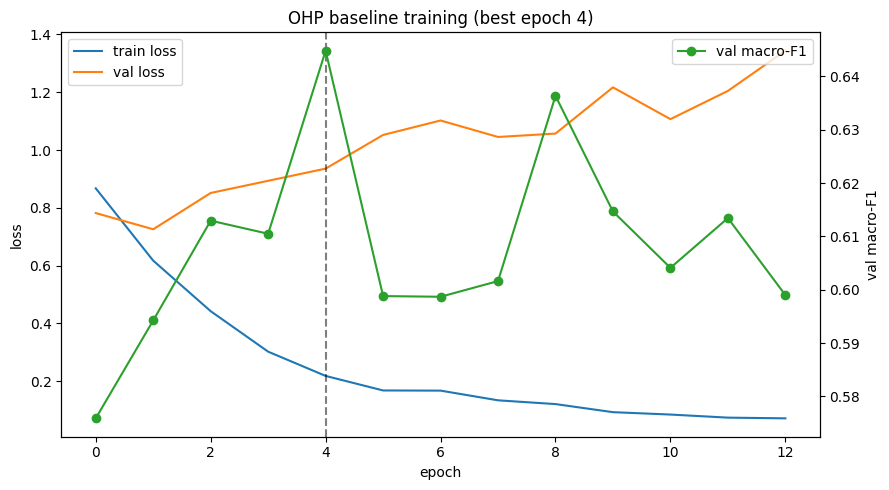

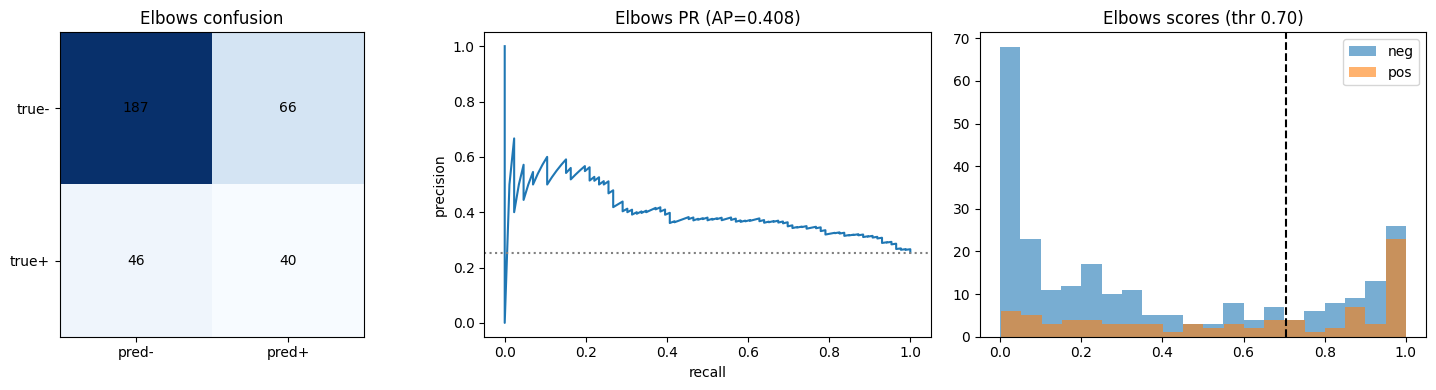

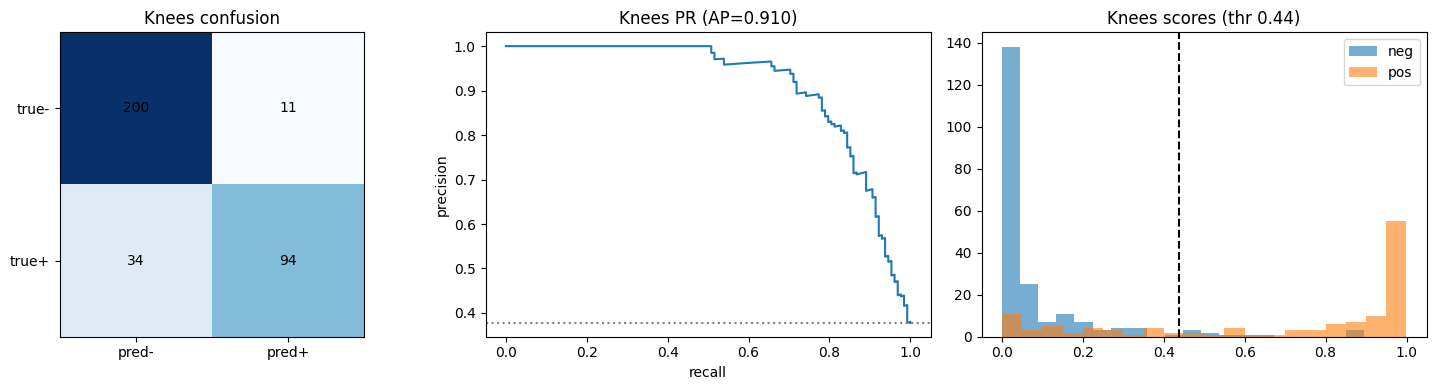

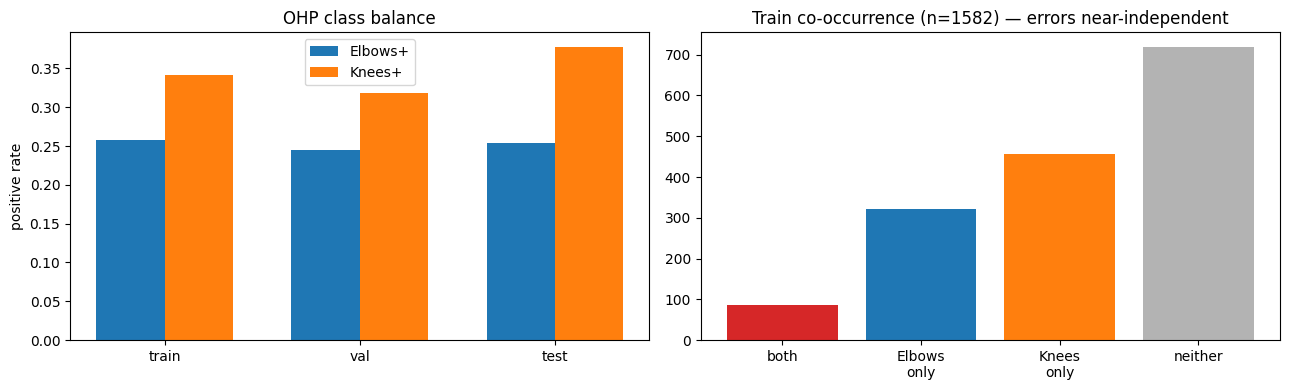

figures saved to .planning/phases/06-overhead-press/figures


In [ ]:
import os, json, pickle
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from backend.training.aqa.datasets.ohp import OHPElbowsKneesDataset
from backend.training.aqa.harness.supervised_train import SupervisedConfig, _build_dataloaders, _val_pass, build_model

FIG = Path("docs/figures"); FIG.mkdir(parents=True, exist_ok=True)
run_dir = os.path.join(MYDRIVE, "FitNova/checkpoints/phase06", "ohp_supervised_v1")

with open(os.path.join(run_dir, "latest.txt")) as f: latest = f.read().strip()
mh = torch.load(os.path.join(run_dir, latest), map_location="cpu", weights_only=False)["metrics_history"]
best = torch.load(os.path.join(run_dir, "best.pt"), map_location="cpu", weights_only=False)
th = best["best_thresholds"]; best_epoch = best["epoch"]
print("epochs:", len(mh), "| metric keys:", list(mh[0].keys()), "| thresholds:", th)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = build_model().to(device); model.load_state_dict(best["model_state_dict"]); model.eval()
loaders = _build_dataloaders(seed=42, config=SupervisedConfig(), drive_root=MYDRIVE, videos_root=VIDEOS_ROOT, dataset_cls=OHPElbowsKneesDataset)
crit = torch.nn.BCEWithLogitsLoss(pos_weight=loaders["test"].dataset.pos_weight.to(device))
_, val_scores, val_labels = _val_pass(model, loaders["val"], crit, device)
_, test_scores, test_labels = _val_pass(model, loaders["test"], crit, device)
del model; torch.cuda.empty_cache()

LAB = Path(ROOT) / "OHP/Labeled_Dataset"
elb = json.load(open(LAB / "Labels/error_elbows.json")); kne = json.load(open(LAB / "Labels/error_knees.json"))
counts = {}
for s in ["train", "val", "test"]:
    ks = json.load(open(LAB / f"Splits/{s}_keys.json"))
    counts[s] = {"n": len(ks), "elbows": sum(bool(elb.get(k)) for k in ks), "knees": sum(bool(kne.get(k)) for k in ks)}
tr = json.load(open(LAB / "Splits/train_keys.json"))
both = sum(bool(elb.get(k)) and bool(kne.get(k)) for k in tr)
e_only = sum(bool(elb.get(k)) and not bool(kne.get(k)) for k in tr)
k_only = sum(not bool(elb.get(k)) and bool(kne.get(k)) for k in tr)
neither = len(tr) - both - e_only - k_only

artifact = {"metrics_history": mh, "best_epoch": best_epoch, "thresholds": th,
            "val_scores": val_scores, "val_labels": val_labels,
            "test_scores": test_scores, "test_labels": test_labels,
            "split_counts": counts, "train_cooccur": {"both": both, "elbows_only": e_only, "knees_only": k_only, "neither": neither}}
art_path = os.path.join(MYDRIVE, "FitNova/phase06_baseline_results.pkl")
with open(art_path, "wb") as f: pickle.dump(artifact, f)
print("saved artifact:", art_path)

ERRORS = ["Elbows", "Knees"]; TH = [th["elbows"], th["knees"]]
ep = list(range(len(mh)))
fig, ax = plt.subplots(figsize=(9, 5)); ax2 = ax.twinx()
ax.plot(ep, [m.get("train_loss", m.get("train_loss_mean", np.nan)) for m in mh], "C0-", label="train loss")
ax.plot(ep, [m.get("val_loss", m.get("val_loss_mean", np.nan)) for m in mh], "C1-", label="val loss")
ax2.plot(ep, [m["val_macro_f1"] for m in mh], "C2-o", label="val macro-F1")
ax.axvline(best_epoch, color="k", ls="--", alpha=0.5)
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax2.set_ylabel("val macro-F1")
ax.legend(loc="upper left"); ax2.legend(loc="upper right"); ax.set_title(f"OHP baseline training (best epoch {best_epoch})")
fig.tight_layout(); fig.savefig(FIG / "ohp_baseline_training_curves.png", dpi=110); plt.show()

for i, name in enumerate(ERRORS):
    y, s, t = test_labels[:, i], test_scores[:, i], TH[i]; pred = (s >= t).astype(int)
    cm = np.array([[int(((pred == 0) & (y == 0)).sum()), int(((pred == 1) & (y == 0)).sum())],
                   [int(((pred == 0) & (y == 1)).sum()), int(((pred == 1) & (y == 1)).sum())]])
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    axs[0].imshow(cm, cmap="Blues")
    for (r, c), v in np.ndenumerate(cm): axs[0].text(c, r, v, ha="center", va="center")
    axs[0].set_xticks([0, 1]); axs[0].set_xticklabels(["pred-", "pred+"]); axs[0].set_yticks([0, 1]); axs[0].set_yticklabels(["true-", "true+"]); axs[0].set_title(f"{name} confusion")
    p, rc, _ = precision_recall_curve(y, s); ap = average_precision_score(y, s)
    axs[1].plot(rc, p); axs[1].axhline(y.mean(), ls=":", color="grey"); axs[1].set_xlabel("recall"); axs[1].set_ylabel("precision"); axs[1].set_title(f"{name} PR (AP={ap:.3f})")
    axs[2].hist(s[y == 0], bins=20, alpha=0.6, label="neg"); axs[2].hist(s[y == 1], bins=20, alpha=0.6, label="pos"); axs[2].axvline(t, color="k", ls="--"); axs[2].set_title(f"{name} scores (thr {t:.2f})"); axs[2].legend()
    fig.tight_layout(); fig.savefig(FIG / f"ohp_baseline_{name.lower()}_eval.png", dpi=110); plt.show()

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
sp = ["train", "val", "test"]; x = np.arange(3); w = 0.35
axs[0].bar(x - w / 2, [counts[s]["elbows"] / counts[s]["n"] for s in sp], w, label="Elbows+")
axs[0].bar(x + w / 2, [counts[s]["knees"] / counts[s]["n"] for s in sp], w, label="Knees+")
axs[0].set_xticks(x); axs[0].set_xticklabels(sp); axs[0].set_ylabel("positive rate"); axs[0].set_title("OHP class balance"); axs[0].legend()
axs[1].bar(["both", "Elbows\nonly", "Knees\nonly", "neither"], [both, e_only, k_only, neither], color=["C3", "C0", "C1", "0.7"])
axs[1].set_title(f"Train co-occurrence (n={len(tr)}) — errors near-independent")
fig.tight_layout(); fig.savefig(FIG / "ohp_eda_balance_cooccurrence.png", dpi=110); plt.show()
print("figures saved to", FIG)

In [ ]:
from sklearn.metrics import f1_score
import numpy as np
T = [th["elbows"], th["knees"]]
for i, name in enumerate(["Elbows", "Knees"]):
    vf = f1_score(val_labels[:, i], (val_scores[:, i] >= T[i]).astype(int))
    tf = f1_score(test_labels[:, i], (test_scores[:, i] >= T[i]).astype(int))
    print(f"{name}: val_F1={vf:.4f}  test_F1={tf:.4f}  gap={vf - tf:+.4f}")
vmac = np.mean([f1_score(val_labels[:, i], (val_scores[:, i] >= T[i]).astype(int)) for i in range(2)])
tmac = np.mean([f1_score(test_labels[:, i], (test_scores[:, i] >= T[i]).astype(int)) for i in range(2)])
print(f"macro: val={vmac:.4f}  test={tmac:.4f}  gap={vmac - tmac:+.4f}")

Elbows: val_F1=0.5146  test_F1=0.4167  gap=+0.0979
Knees: val_F1=0.7980  test_F1=0.8069  gap=-0.0089
macro: val=0.6563  test=0.6118  gap=+0.0445
